# RSO-656 — DIMM vs ConsDB donut-blur cross-check

The telemetry notebook (`RSO-656 DIMM telemetry exploration.ipynb`) showed, using DIMM-internal
data only, that DIMM seeing **collapses to artificially low values when `flux_proxy = fluxL + fluxR`
drops below ~12k ADU** (Erik D.'s cloud hypothesis). That result rests on a single instrument.

This notebook brings in an **independent witness**: the camera's donut-blur seeing from ConsDB,
`donut_blur_atm_fwhm = sqrt(donut_blur_fwhm² − CAM_FWHM²)` (`CAM_FWHM = 0.207″`). If the cloud
hypothesis is right, then in the low-flux regime the **DIMM should read low while the donut-blur
seeing stays high** — i.e. the atmosphere did not actually improve, the DIMM just lost light.

**Plan**
1. Load ConsDB per-visit image-quality (prefer the cached CSV for this date range).
2. Re-pull DIMM `logevent_dimmMeasurement`, rebuild `flux_proxy`.
3. Time-join each visit to the nearest DIMM measurement (`merge_asof`).
4. Compare DIMM `fwhm` vs `donut_blur_atm_fwhm`, split by flux regime; quantify the DIMM error
   as a function of `flux_proxy`.

See [`HANDOFF.md`](./HANDOFF.md) for state and [`FINDINGS.md`](./FINDINGS.md) for results.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.time import Time

from lsst.summit.utils.efdUtils import (
    getEfdData,
    getDayObsStartTime,
    getDayObsEndTime,
)
# Seeing corrections: normalise to zenith (airmass) and to 500 nm (bandpass).
from lsst.summit.utils import getAirmassSeeingCorrection, getBandpassSeeingCorrection

# makeEfdClient() is currently broken on this kernel; use EfdClient directly (see the
# telemetry notebook). output_mode='dataframe' is required for getEfdData to work.
from lsst_efd_client import EfdClient

warnings.filterwarnings("ignore")

CAM_FWHM = 0.207  # arcsec, assumed camera-contribution FWHM (repo convention)
FLUX_THRESHOLD = 12000  # ADU; below this DIMM seeing was found unreliable (telemetry notebook)

PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

## 1. Configuration

Use the **same `dayObs` range as the telemetry notebook** so the DIMM and ConsDB pulls line up.
A matching ConsDB cache already exists one level up: `../consdb_20260119_20260407.csv` — prefer
reading it over re-querying.

In [3]:
day_obs_begin = 20260119
day_obs_end = 20260407
instrument = "lsstcam"

# ConsDB cache written by the image_quality notebooks (same date range).
CONSDB_CACHE = f"../consdb_{day_obs_begin}_{day_obs_end}.csv"

efd_client = EfdClient("usdf_efd", output_mode="dataframe")

start_time = getDayObsStartTime(day_obs_begin)
end_time = getDayObsEndTime(day_obs_end)
print(f"Querying {start_time.isot}  ->  {end_time.isot}")

Querying 2026-01-19T12:00:00.000  ->  2026-04-08T12:00:00.000


## 2. ConsDB per-visit image quality

Read the cached CSV if present, else query ConsDB. The cache already carries the derived
`donut_blur_atm_fwhm`; if we query fresh we recompute it. We then reduce to **one row per visit**
(median over detectors) and normalise the donut-blur seeing to a common frame before any
comparison:

- **camera term** removed: `donut_blur_atm_fwhm = sqrt(donut_blur_fwhm² − CAM_FWHM²)`,
- **airmass** → zenith via `getAirmassSeeingCorrection(airmass)` (seeing ∝ airmass^0.6),
- **wavelength** → 500 nm via `getBandpassSeeingCorrection(physical_filter)` (seeing ∝ λ^−0.2).

The fully-corrected column is `donut_blur_zen500`. This matters because visits span airmass
1.0–5.9 and multiple bands, while the DIMM runs at a fixed ~500 nm — without these corrections the
comparison would carry a large airmass/band offset. As an independent check we also keep ConsDB's
own pre-corrected `seeing_zenith_500nm_median`.

In [4]:
def query_consdb(day_obs_min, day_obs_max):
    """Fallback query if the cache is missing. Mirrors image_quality_minimal.ipynb."""
    from lsst.summit.utils import ConsDbClient

    os.environ["no_proxy"] += ",.consdb"
    client = ConsDbClient("http://consdb-pq.consdb:8080/consdb")
    q = f"""
    SELECT
      ccdvisit1_quicklook.psf_sigma,
      visit1.visit_id, visit1.band, visit1.physical_filter, visit1.day_obs,
      visit1.airmass, visit1.exp_midpt_mjd, visit1.dimm_seeing,
      visit1_quicklook.donut_blur_fwhm, visit1_quicklook.aos_fwhm,
      visit1_quicklook.seeing_zenith_500nm_median
    FROM
      cdb_{instrument}.ccdvisit1_quicklook AS ccdvisit1_quicklook,
      cdb_{instrument}.ccdvisit1 AS ccdvisit1,
      cdb_{instrument}.visit1_quicklook AS visit1_quicklook,
      cdb_{instrument}.visit1 AS visit1
    WHERE ccdvisit1.ccdvisit_id = ccdvisit1_quicklook.ccdvisit_id
      AND ccdvisit1.visit_id = visit1.visit_id
      AND visit1.visit_id = visit1_quicklook.visit_id
      AND visit1.airmass > 0
      AND visit1.day_obs >= {day_obs_min} AND visit1.day_obs <= {day_obs_max};
    """
    df = client.query(q).to_pandas()
    for c in ["donut_blur_fwhm", "aos_fwhm", "dimm_seeing", "exp_midpt_mjd", "airmass"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["donut_blur_atm_fwhm"] = np.sqrt(df["donut_blur_fwhm"] ** 2 - CAM_FWHM ** 2)
    return df


if os.path.exists(CONSDB_CACHE):
    print(f"Reading cache {CONSDB_CACHE}")
    ccdvisits = pd.read_csv(CONSDB_CACHE, low_memory=False)
    if "donut_blur_atm_fwhm" not in ccdvisits:
        ccdvisits["donut_blur_atm_fwhm"] = np.sqrt(
            pd.to_numeric(ccdvisits["donut_blur_fwhm"], errors="coerce") ** 2 - CAM_FWHM ** 2
        )
else:
    print("Cache not found - querying ConsDB")
    ccdvisits = query_consdb(day_obs_begin, day_obs_end)

for c in ["donut_blur_atm_fwhm", "donut_blur_fwhm", "dimm_seeing", "exp_midpt_mjd",
          "airmass", "seeing_zenith_500nm_median"]:
    if c in ccdvisits:
        ccdvisits[c] = pd.to_numeric(ccdvisits[c], errors="coerce")
print(f"{len(ccdvisits)} ccdvisit rows")

Reading cache ../consdb_20260119_20260407.csv


1444296 ccdvisit rows


In [5]:
# One row per visit (median over detectors), then a UTC timestamp from exp_midpt_mjd.
has_zen = "seeing_zenith_500nm_median" in ccdvisits
g = ccdvisits.groupby("visit_id")
visits = pd.DataFrame({
    "day_obs": g["day_obs"].first(),
    "band": g["band"].first(),
    "physical_filter": g["physical_filter"].first(),
    "airmass": g["airmass"].median(),
    "exp_midpt_mjd": g["exp_midpt_mjd"].median(),
    "donut_blur_atm_fwhm": g["donut_blur_atm_fwhm"].median(),
    "dimm_seeing_consdb": g["dimm_seeing"].median(),
    **({"seeing_zenith_500nm_median": g["seeing_zenith_500nm_median"].median()} if has_zen else {}),
}).reset_index()

# Normalise donut-blur seeing to zenith and 500 nm so it is directly comparable to the
# fixed-wavelength DIMM. Corrections are per-visit scalars from the summit_utils helpers.
airmass_corr = np.array([getAirmassSeeingCorrection(a) for a in visits["airmass"]])
band_corr = np.array([getBandpassSeeingCorrection(f) for f in visits["physical_filter"]])
visits["donut_blur_zen500"] = visits["donut_blur_atm_fwhm"] * airmass_corr * band_corr

visits = visits[visits["exp_midpt_mjd"].notna()].copy()
visits["time"] = pd.to_datetime(
    Time(visits["exp_midpt_mjd"].values, format="mjd", scale="utc").isot, utc=True
)
# 'y' donut blur is known-unreliable in the IQ notebooks; drop it here too.
visits = visits[visits["band"] != "y"].sort_values("time").reset_index(drop=True)
print(f"{len(visits)} visits with a usable donut-blur seeing")
cols = ["donut_blur_atm_fwhm", "donut_blur_zen500", "dimm_seeing_consdb", "airmass"]
if has_zen:
    cols.insert(2, "seeing_zenith_500nm_median")
visits[cols].describe()

6909 visits with a usable donut-blur seeing


,donut_blur_atm_fwhm,donut_blur_zen500,seeing_zenith_500nm_median,dimm_seeing_consdb,airmass
count,6903.000000,6903.000000,0.0,5127.000000,6909.000000
mean,0.867502,0.828367,NaN,1.156098,1.258759
std,0.243349,0.207281,NaN,2.149300,0.281227
min,0.468754,0.390490,NaN,0.467505,1.008812
25%,0.735717,0.709138,NaN,0.795639,1.086587
50%,0.821359,0.798983,NaN,0.988636,1.164127
75%,0.934390,0.905967,NaN,1.206236,1.315151
max,4.495028,3.803778,NaN,39.895573,3.341459


## 3. DIMM measurements + flux proxy

Re-pull the same DIMM event as the telemetry notebook and rebuild `flux_proxy = fluxL + fluxR`.

**Airmass convention is unknown for our DIMM.** The EFD field is documented only as "Combined
FWHM"; it may already be zenith-corrected, or it may be line-of-sight at the reported `secz`. To
avoid baking in the wrong assumption we carry **both**:

- `dimm_fwhm` — the raw EFD value (correct if the DIMM already reports at zenith),
- `dimm_fwhm_zen` = `dimm_fwhm × getAirmassSeeingCorrection(secz)` (correct if it is line-of-sight).

No bandpass correction is applied to the DIMM — it runs at a fixed ~500 nm. The comparison in §5
is shown against both so the conclusion does not hinge on the unknown convention.

In [6]:
dimm = getEfdData(
    efd_client,
    topic="lsst.sal.DIMM.logevent_dimmMeasurement",
    columns=["fwhm", "fluxL", "fluxR", "strehlL", "strehlR", "secz"],
    begin=start_time,
    end=end_time,
)
dimm["flux_proxy"] = dimm["fluxL"] + dimm["fluxR"]
dimm = dimm.sort_index()

# Zenith-corrected DIMM variant, in case the EFD fwhm is line-of-sight at `secz`.
dimm_airmass_corr = np.array([getAirmassSeeingCorrection(z) for z in dimm["secz"]])
dimm["fwhm_zen"] = dimm["fwhm"] * dimm_airmass_corr

# merge_asof needs the join key as a tz-aware column matching `visits['time']`.
dimm_j = dimm.reset_index().rename(columns={dimm.index.name or "index": "time"})
dimm_j = dimm_j.rename(columns={"fwhm": "dimm_fwhm", "fwhm_zen": "dimm_fwhm_zen"})
print(f"{len(dimm_j)} DIMM measurements; time dtype = {dimm_j['time'].dtype}")
dimm_j[["time", "dimm_fwhm", "dimm_fwhm_zen", "flux_proxy", "secz"]].head()

28743 DIMM measurements; time dtype = datetime64[ns, UTC]


,time,dimm_fwhm,dimm_fwhm_zen,flux_proxy,secz
0,2026-01-20 00:36:41.377236+00:00,1.049579,0.920710,24747,1.244
1,2026-01-20 00:37:41.630488+00:00,1.051290,0.923548,24605,1.241
2,2026-01-20 00:38:43.838943+00:00,0.973772,0.856692,24400,1.238
3,2026-01-20 00:39:44.287677+00:00,1.001145,0.882486,23975,1.234
4,2026-01-20 00:40:43.675218+00:00,0.997784,0.880809,24311,1.231


## 4. Time-join: nearest DIMM measurement per visit

Match each visit's `exp_midpt_mjd` to the nearest DIMM measurement within a tolerance. DIMM cadence
is ~1 min; a 5-min tolerance tolerates gaps while keeping the pairing tight. Visits with no DIMM
sample nearby are dropped.

In [7]:
paired = pd.merge_asof(
    visits,
    dimm_j[["time", "dimm_fwhm", "dimm_fwhm_zen", "flux_proxy", "strehlL", "strehlR", "secz"]],
    on="time",
    direction="nearest",
    tolerance=pd.Timedelta("5min"),
)

paired = paired[paired["dimm_fwhm"].notna() & paired["donut_blur_zen500"].notna()].copy()
# DIMM residual vs the zenith/500nm donut-blur reference. Negative => DIMM reads LOWER
# than the independent camera seeing. Computed for both DIMM airmass conventions.
paired["resid_raw"] = paired["dimm_fwhm"] - paired["donut_blur_zen500"]
paired["resid_zen"] = paired["dimm_fwhm_zen"] - paired["donut_blur_zen500"]
paired["low_flux"] = paired["flux_proxy"] < FLUX_THRESHOLD

n_lo = int(paired["low_flux"].sum())
print(f"{len(paired)} visit<->DIMM pairs  ({n_lo} in the low-flux regime, "
      f"flux_proxy < {FLUX_THRESHOLD})")
paired[["dimm_fwhm", "dimm_fwhm_zen", "donut_blur_zen500", "resid_raw", "resid_zen",
        "flux_proxy"]].describe()

5482 visit<->DIMM pairs  (40 in the low-flux regime, flux_proxy < 12000)


,dimm_fwhm,dimm_fwhm_zen,donut_blur_zen500,resid_raw,resid_zen,flux_proxy
count,5482.000000,5482.000000,5482.000000,5482.000000,5482.000000,5482.000000
mean,1.182955,1.118955,0.824164,0.358791,0.294791,35848.610908
std,2.490227,2.338613,0.199866,2.498987,2.347732,48887.392010
min,0.492599,0.464572,0.390490,-2.873124,-2.894244,6976.000000
25%,0.778578,0.732003,0.709197,-0.008090,-0.062124,17807.000000
50%,0.962750,0.902424,0.803384,0.145541,0.089949,19192.500000
75%,1.183583,1.127110,0.903228,0.332629,0.280319,25049.250000
max,41.693714,39.354845,3.803778,40.992340,38.653471,225741.000000


## 5. Low-flux-regime comparison

Both instruments are now on the **same frame** (zenith, 500 nm): `donut_blur_zen500` on the camera
side, and DIMM shown as both raw and zenith-corrected.

**Left:** DIMM `fwhm` vs `donut_blur_zen500`, split by flux regime, with the 1:1 line. If the cloud
hypothesis holds, the **low-flux points fall below the 1:1 line** — DIMM reads low while the camera
still sees a broad PSF (the atmosphere did not actually improve).

**Right:** the DIMM residual binned against `flux_proxy`, plotted for **both** DIMM airmass
conventions (raw and zenith-corrected). The hypothesis predicts a residual that goes
**increasingly negative as flux drops**; the two curves bracket the airmass-convention uncertainty.

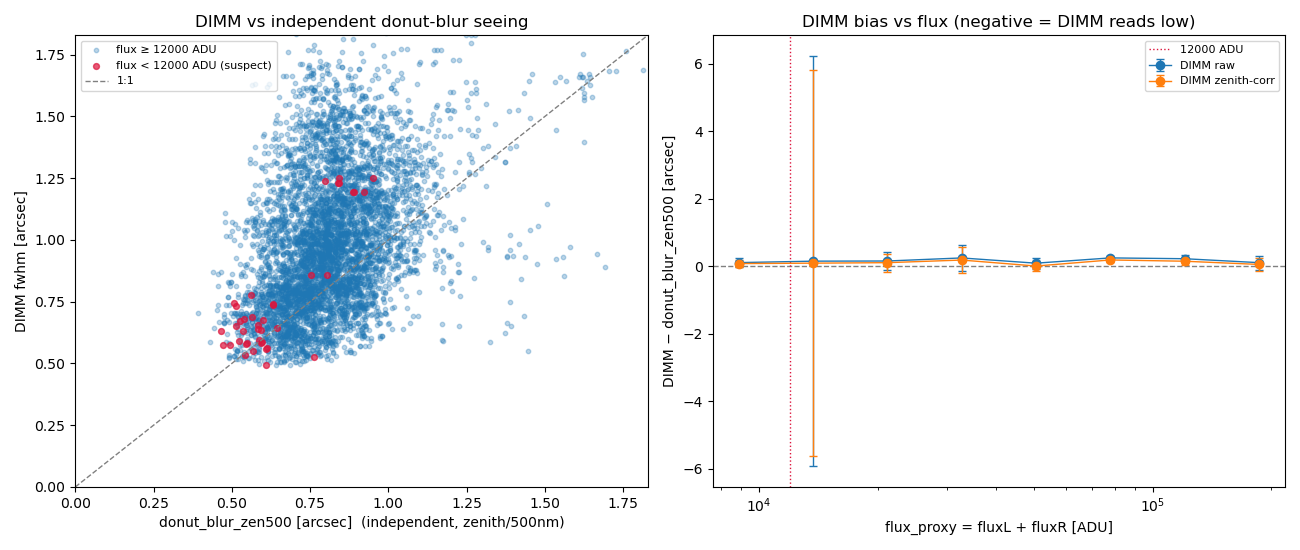

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# --- Left: DIMM (raw) vs zenith/500nm donut-blur, coloured by flux regime ---
hi = ~paired["low_flux"]
lo = paired["low_flux"]
ax = axes[0]
ax.scatter(paired.loc[hi, "donut_blur_zen500"], paired.loc[hi, "dimm_fwhm"],
           s=10, alpha=0.3, label=f"flux ≥ {FLUX_THRESHOLD} ADU")
ax.scatter(paired.loc[lo, "donut_blur_zen500"], paired.loc[lo, "dimm_fwhm"],
           s=18, alpha=0.7, color="crimson", label=f"flux < {FLUX_THRESHOLD} ADU (suspect)")
lim = [0, np.nanpercentile(paired[["dimm_fwhm", "donut_blur_zen500"]].values, 99)]
ax.plot(lim, lim, ls="--", color="grey", lw=1, label="1:1")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("donut_blur_zen500 [arcsec]  (independent, zenith/500nm)")
ax.set_ylabel("DIMM fwhm [arcsec]")
ax.set_title("DIMM vs independent donut-blur seeing")
ax.legend(fontsize=8, loc="upper left")

# --- Right: DIMM residual vs flux_proxy, both airmass conventions ---
ax = axes[1]
fp = paired["flux_proxy"].replace(0, np.nan)
bins = np.geomspace(np.nanmin(fp), np.nanmax(fp), 9)
paired["_fbin"] = pd.cut(fp, bins=bins)
for col, lbl in [("resid_raw", "DIMM raw"), ("resid_zen", "DIMM zenith-corr")]:
    gb = paired.groupby("_fbin", observed=True)[col]
    centers = [iv.mid for iv in gb.median().index]
    ax.errorbar(centers, gb.median(), yerr=gb.std(), marker="o", capsize=3, lw=1, label=lbl)
ax.axhline(0, ls="--", color="grey", lw=1)
ax.axvline(FLUX_THRESHOLD, ls=":", color="crimson", lw=1, label=f"{FLUX_THRESHOLD} ADU")
ax.set_xscale("log")
ax.set_xlabel("flux_proxy = fluxL + fluxR [ADU]")
ax.set_ylabel("DIMM − donut_blur_zen500 [arcsec]")
ax.set_title("DIMM bias vs flux (negative = DIMM reads low)")
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/dimm_vs_donut_blur_{day_obs_begin}_{day_obs_end}.png", dpi=120)
plt.show()

In [9]:
# Numeric summary: DIMM residual (both conventions) by flux regime.
summary = paired.groupby("low_flux").agg(
    n=("dimm_fwhm", "size"),
    dimm_fwhm_median=("dimm_fwhm", "median"),
    donut_zen500_median=("donut_blur_zen500", "median"),
    resid_raw_median=("resid_raw", "median"),
    resid_zen_median=("resid_zen", "median"),
)
summary.index = summary.index.map({False: f"flux ≥ {FLUX_THRESHOLD}", True: f"flux < {FLUX_THRESHOLD}"})
print("DIMM residual vs zenith/500nm donut-blur, by flux regime "
      "(negative = DIMM reads low):")
summary

DIMM residual vs zenith/500nm donut-blur, by flux regime (negative = DIMM reads low):


,n,dimm_fwhm_median,donut_zen500_median,resid_raw_median,resid_zen_median
low_flux,,,,,
flux ≥ 12000,5442,0.964110,0.803890,0.146055,0.090334
flux < 12000,40,0.654366,0.591911,0.099137,0.056719


## 6. Next

- Read the residual table/figure: the cloud hypothesis is confirmed against an independent
  instrument iff `resid_*_median` is clearly **negative in the low-flux regime** and near zero
  above threshold — **for both** airmass conventions (`resid_raw` and `resid_zen`). If the two
  conventions disagree in sign, resolve the DIMM airmass convention before concluding.
- Cross-check the correction: overlay ConsDB's own `seeing_zenith_500nm_median` against our
  manual `donut_blur_zen500` — they should track, validating the airmass/bandpass step.
- Sanity check the join: how many low-flux pairs survive? If few, widen the date range or relax
  the 5-min tolerance, and confirm the pairing isn't dominated by one night.
- Record the result in `FINDINGS.md` §4 and finalise §6 for Craig.